# ANOVA Elbow Curve: Prosody Energy

This notebook sweeps the number of top-ANOVA features (`k`) and measures model performance to identify the elbow point where gains begin to plateau.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.style.use('ggplot')
np.random.seed(42)


In [14]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / '.git').exists() or (p / 'pyproject.toml').exists():
            return p
    return start


def build_k_values(n_features: int) -> list[int]:
    if n_features <= 30:
        vals = list(range(1, n_features + 1))
    else:
        grid = np.unique(np.r_[
            np.arange(5, min(51, n_features + 1), 5),
            np.arange(60, min(301, n_features + 1), 10),
            np.linspace(320, n_features, 12, dtype=int),
            [n_features],
        ])
        vals = [int(v) for v in grid if 1 <= int(v) <= n_features]
        if 1 not in vals:
            vals = [1] + vals
    return sorted(set(vals))


def smooth(values: np.ndarray, window: int = 3) -> np.ndarray:
    if len(values) < window:
        return values.copy()
    pad = window // 2
    padded = np.pad(values, (pad, pad), mode='edge')
    kernel = np.ones(window) / window
    return np.convolve(padded, kernel, mode='valid')


def detect_elbow(k_values: np.ndarray, metric_values: np.ndarray) -> tuple[int, int]:
    x = k_values.astype(float)
    y = metric_values.astype(float)

    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

    p0 = np.array([x_norm[0], y_norm[0]])
    p1 = np.array([x_norm[-1], y_norm[-1]])
    line = p1 - p0
    line_norm = np.linalg.norm(line) + 1e-12

    points = np.column_stack([x_norm, y_norm])
    dists = np.abs(np.cross(line, points - p0) / line_norm)

    elbow_idx = int(np.argmax(dists))
    best_idx = int(np.argmax(y))
    return elbow_idx, best_idx


In [15]:
# Config
DATASET_KEY = 'prosody_energy'
DISPLAY_NAME = 'Prosody Energy'
SOURCE_CSV = Path('extracted_features/prosody_energy/prosody_energy_features.csv')
TARGET_COL = 'emotion'
TEST_SIZE = 0.2
RANDOM_STATE = 42

REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / SOURCE_CSV
ARTIFACT_DIR = REPO_ROOT / 'feature_selection' / 'filter' / 'select_k_best_anova' / 'artifacts'
RANK_PATH = ARTIFACT_DIR / f'{DATASET_KEY}_anova_ranking.csv'

print('Dataset:', DISPLAY_NAME)
print('DATA_PATH:', DATA_PATH)
print('RANK_PATH:', RANK_PATH)


Dataset: Prosody Energy
DATA_PATH: /home/beka/Speech-Emotion-Recognition/extracted_features/prosody_energy/prosody_energy_features.csv
RANK_PATH: /home/beka/Speech-Emotion-Recognition/feature_selection/filter/select_k_best_anova/artifacts/prosody_energy_anova_ranking.csv


In [16]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Missing source CSV for {DATASET_KEY}: {DATA_PATH}\n'
        'Generate/copy this family CSV first, then rerun.'
    )

if not RANK_PATH.exists():
    raise FileNotFoundError(
        f'Missing ANOVA ranking CSV: {RANK_PATH}\n'
        'Run the corresponding ANOVA notebook first, then rerun.'
    )

df = pd.read_csv(DATA_PATH)
rank_df = pd.read_csv(RANK_PATH)

selected_features_path = ARTIFACT_DIR / f'{DATASET_KEY}_selected_features.json'

def _looks_like_lfs_pointer(path: Path) -> bool:
    try:
        head = path.read_text(encoding='utf-8', errors='ignore').splitlines()[:3]
    except OSError:
        return False
    return bool(head) and head[0].startswith('version https://git-lfs.github.com/spec/v1')

if 'feature' in rank_df.columns:
    feature_order = rank_df['feature'].dropna().astype(str).tolist()
elif selected_features_path.exists():
    import json
    with selected_features_path.open('r', encoding='utf-8') as f:
        feature_order = json.load(f)
    print(f"Warning: 'feature' column missing in {RANK_PATH.name}; using {selected_features_path.name} fallback.")
else:
    if _looks_like_lfs_pointer(RANK_PATH):
        raise ValueError(
            f"{RANK_PATH} is a Git LFS pointer, not the real CSV. "
            "Run: git lfs pull (or git lfs checkout) and rerun."
        )
    raise ValueError(
        f"Ranking file has no 'feature' column: {RANK_PATH}. "
        f"Columns found: {list(rank_df.columns)}"
    )

feature_order = [str(f) for f in feature_order if str(f) in df.columns]

if TARGET_COL not in df.columns:
    raise ValueError(f'Target column not found: {TARGET_COL}')

if not feature_order:
    raise ValueError('No overlap between ANOVA-ranked features and dataset columns.')

model_df = df[[TARGET_COL] + feature_order].copy()
rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL]).dropna(axis=0, how='any')
rows_after = len(model_df)

X = model_df[feature_order].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Num classes: {len(label_enc.classes_)}')
print(f'Num ANOVA-ranked features available: {len(feature_order)}')


KeyError: 'feature'

In [ ]:
k_values = build_k_values(len(feature_order))
results = []

for k in k_values:
    selected = feature_order[:k]
    X_train_k = X_train[selected]
    X_test_k = X_test[selected]

    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])

    clf.fit(X_train_k, y_train)
    pred = clf.predict(X_test_k)

    results.append({
        'k': k,
        'accuracy': accuracy_score(y_test, pred),
        'f1_weighted': f1_score(y_test, pred, average='weighted'),
    })

results_df = pd.DataFrame(results).sort_values('k', ignore_index=True)
results_df['accuracy_smooth'] = smooth(results_df['accuracy'].values)
results_df['f1_weighted_smooth'] = smooth(results_df['f1_weighted'].values)

k_arr = results_df['k'].to_numpy()
acc_arr = results_df['accuracy_smooth'].to_numpy()
f1_arr = results_df['f1_weighted_smooth'].to_numpy()

acc_elbow_idx, acc_best_idx = detect_elbow(k_arr, acc_arr)
f1_elbow_idx, f1_best_idx = detect_elbow(k_arr, f1_arr)

print('Elbow summary')
print('-------------')
print(f"Accuracy elbow k:     {int(k_arr[acc_elbow_idx])}")
print(f"Accuracy best k:      {int(k_arr[acc_best_idx])}")
print(f"Weighted F1 elbow k:  {int(k_arr[f1_elbow_idx])}")
print(f"Weighted F1 best k:   {int(k_arr[f1_best_idx])}")

results_df.head()


Elbow summary
-------------
Accuracy elbow k:     5
Accuracy best k:      7
Weighted F1 elbow k:  5
Weighted F1 best k:   7


/tmp/ipykernel_1190053/2103526712.py:46: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = np.abs(np.cross(line, points - p0) / line_norm)


,k,accuracy,f1_weighted,accuracy_smooth,f1_weighted_smooth
0,1,0.192113,0.151896,0.191776,0.152525
1,2,0.191102,0.153782,0.194473,0.158556
2,3,0.200202,0.169989,0.210482,0.179272
3,4,0.240142,0.214044,0.226660,0.199256
4,5,0.239636,0.213735,0.244186,0.218154


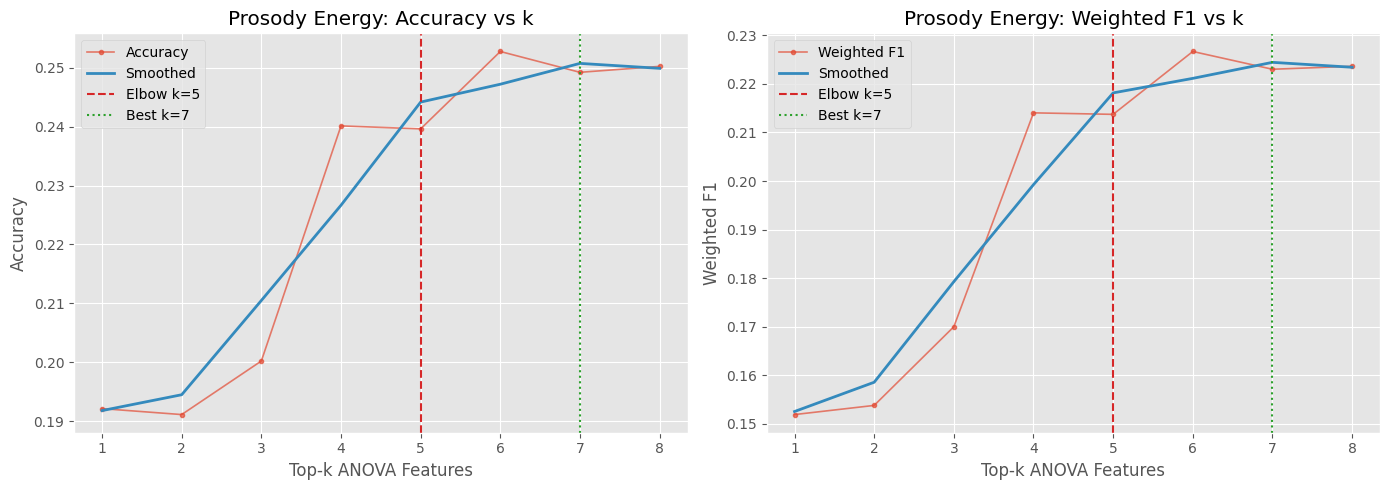

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy elbow
axes[0].plot(results_df['k'], results_df['accuracy'], marker='o', ms=3, lw=1.2, alpha=0.7, label='Accuracy')
axes[0].plot(results_df['k'], results_df['accuracy_smooth'], lw=2, label='Smoothed')
axes[0].axvline(k_arr[acc_elbow_idx], color='tab:red', ls='--', lw=1.5, label=f'Elbow k={int(k_arr[acc_elbow_idx])}')
axes[0].axvline(k_arr[acc_best_idx], color='tab:green', ls=':', lw=1.5, label=f'Best k={int(k_arr[acc_best_idx])}')
axes[0].set_title(f'{DISPLAY_NAME}: Accuracy vs k')
axes[0].set_xlabel('Top-k ANOVA Features')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Weighted F1 elbow
axes[1].plot(results_df['k'], results_df['f1_weighted'], marker='o', ms=3, lw=1.2, alpha=0.7, label='Weighted F1')
axes[1].plot(results_df['k'], results_df['f1_weighted_smooth'], lw=2, label='Smoothed')
axes[1].axvline(k_arr[f1_elbow_idx], color='tab:red', ls='--', lw=1.5, label=f'Elbow k={int(k_arr[f1_elbow_idx])}')
axes[1].axvline(k_arr[f1_best_idx], color='tab:green', ls=':', lw=1.5, label=f'Best k={int(k_arr[f1_best_idx])}')
axes[1].set_title(f'{DISPLAY_NAME}: Weighted F1 vs k')
axes[1].set_xlabel('Top-k ANOVA Features')
axes[1].set_ylabel('Weighted F1')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
summary_df = pd.DataFrame({
    'metric': ['accuracy', 'f1_weighted'],
    'elbow_k': [int(k_arr[acc_elbow_idx]), int(k_arr[f1_elbow_idx])],
    'best_k': [int(k_arr[acc_best_idx]), int(k_arr[f1_best_idx])],
    'elbow_score': [float(results_df.loc[acc_elbow_idx, 'accuracy']), float(results_df.loc[f1_elbow_idx, 'f1_weighted'])],
    'best_score': [float(results_df.loc[acc_best_idx, 'accuracy']), float(results_df.loc[f1_best_idx, 'f1_weighted'])],
})

summary_df


,metric,elbow_k,best_k,elbow_score,best_score
0,accuracy,5,7,0.239636,0.249242
1,f1_weighted,5,7,0.213735,0.223023


In [ ]:
OUT_DIR = REPO_ROOT / 'feature_selection' / 'filter' / 'elbow_curves_anova' / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

results_path = OUT_DIR / f'{DATASET_KEY}_elbow_curve_scores.csv'
summary_path = OUT_DIR / f'{DATASET_KEY}_elbow_summary.csv'

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print('Saved:')
print(' -', results_path)
print(' -', summary_path)


Saved:
 - /home/beka/Speech-Emotion-Recognition/feature_selection/filter/elbow_curves_anova/artifacts/prosody_energy_elbow_curve_scores.csv
 - /home/beka/Speech-Emotion-Recognition/feature_selection/filter/elbow_curves_anova/artifacts/prosody_energy_elbow_summary.csv
